<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Quantum_Simulation_and_Quantum_Solvers_Taxomony_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.13.15 environment at: /usr
Resolved 15 packages in 241ms
Prepared 1 package in 350ms
Installed 1 package in 141ms
 + jedi==0.20.0


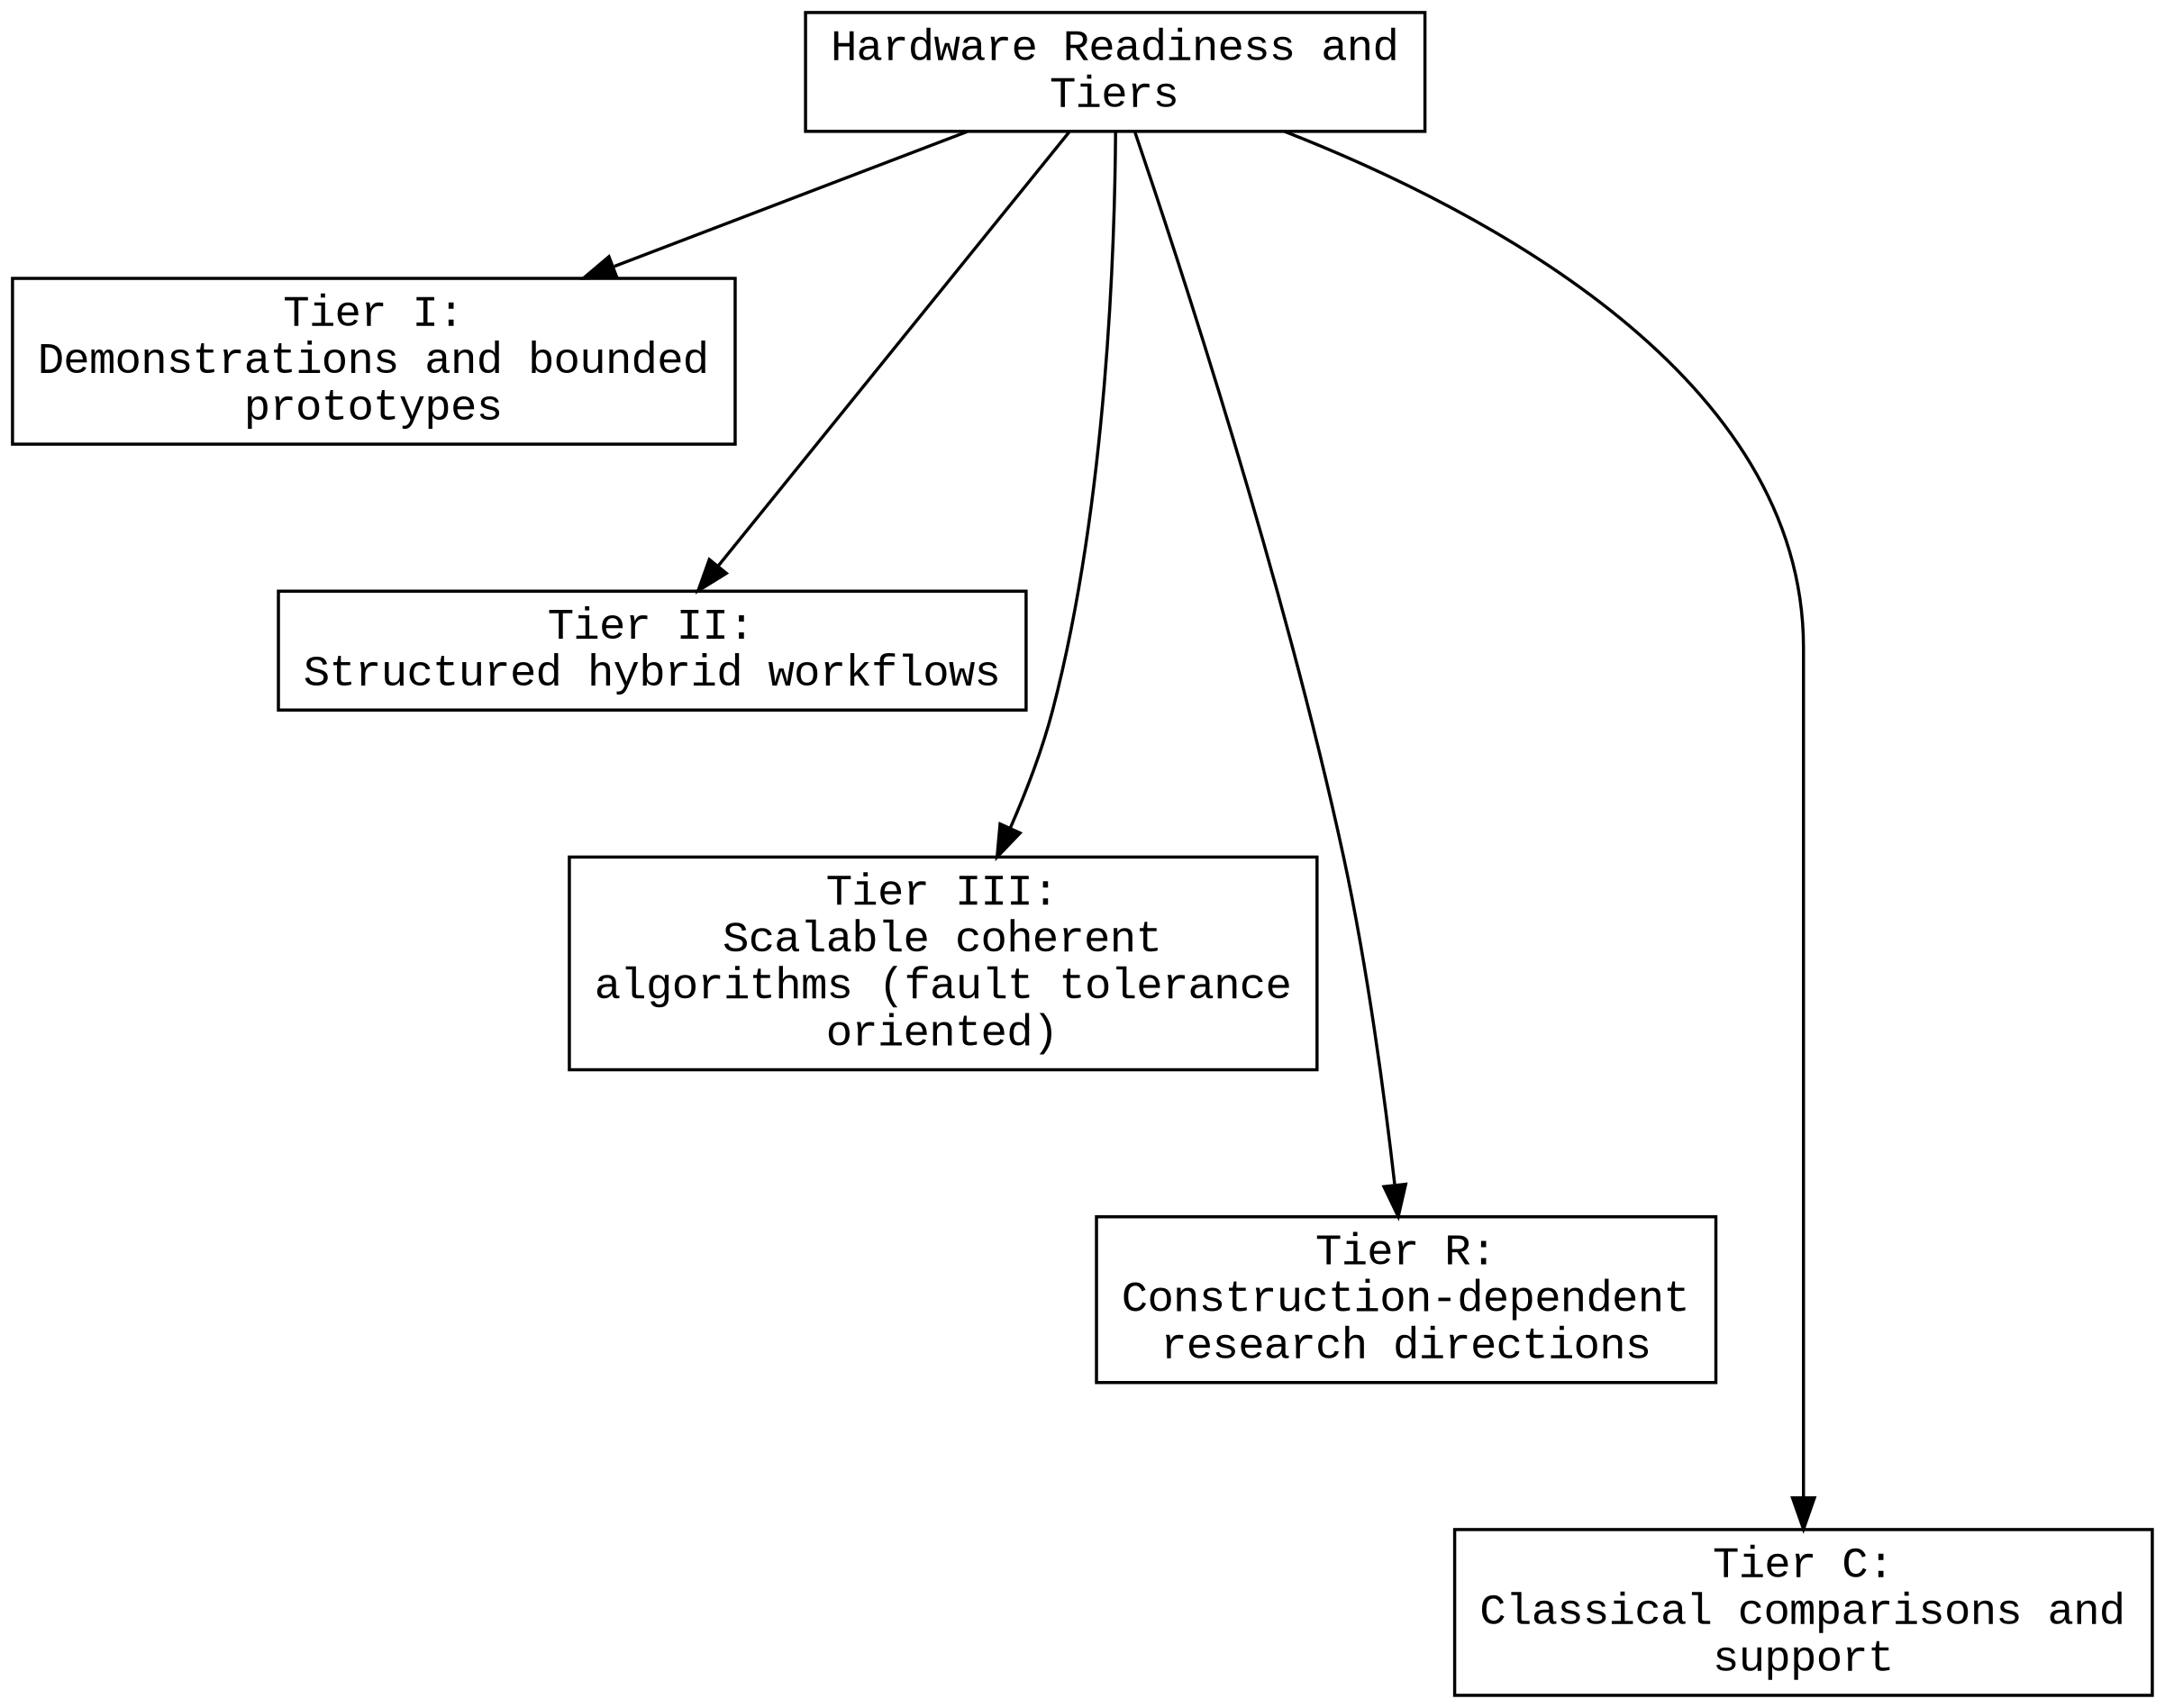

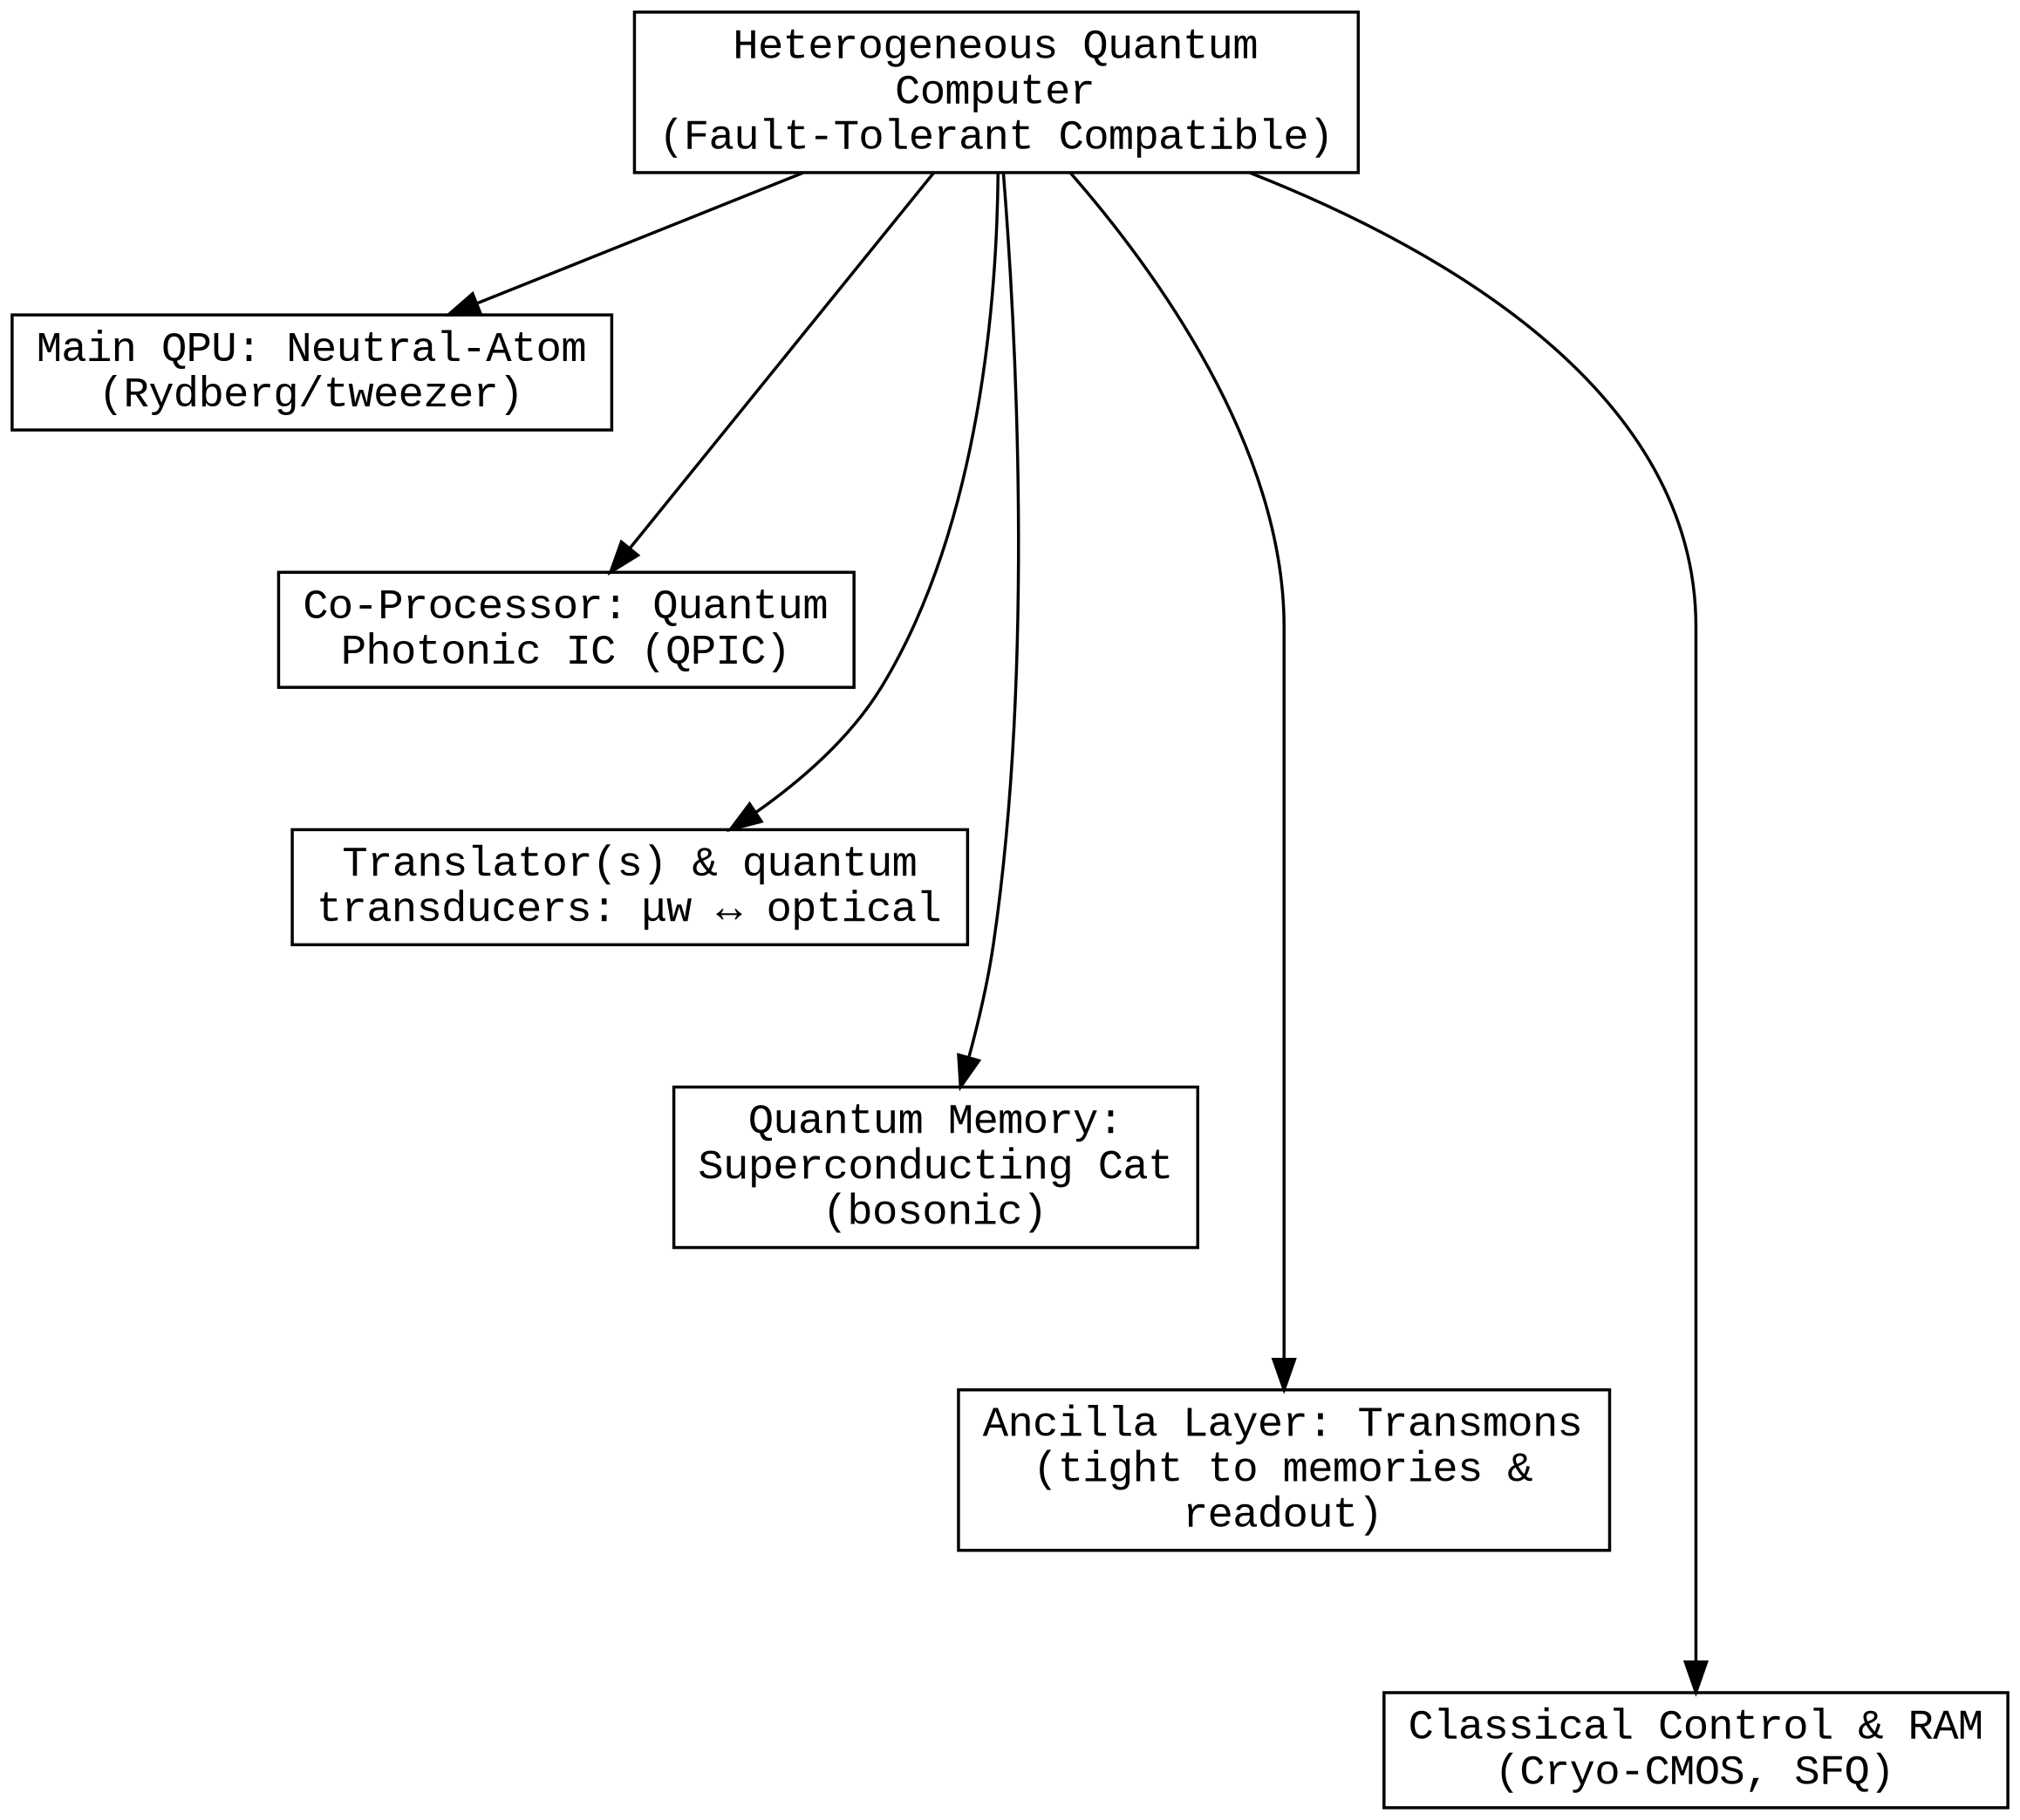

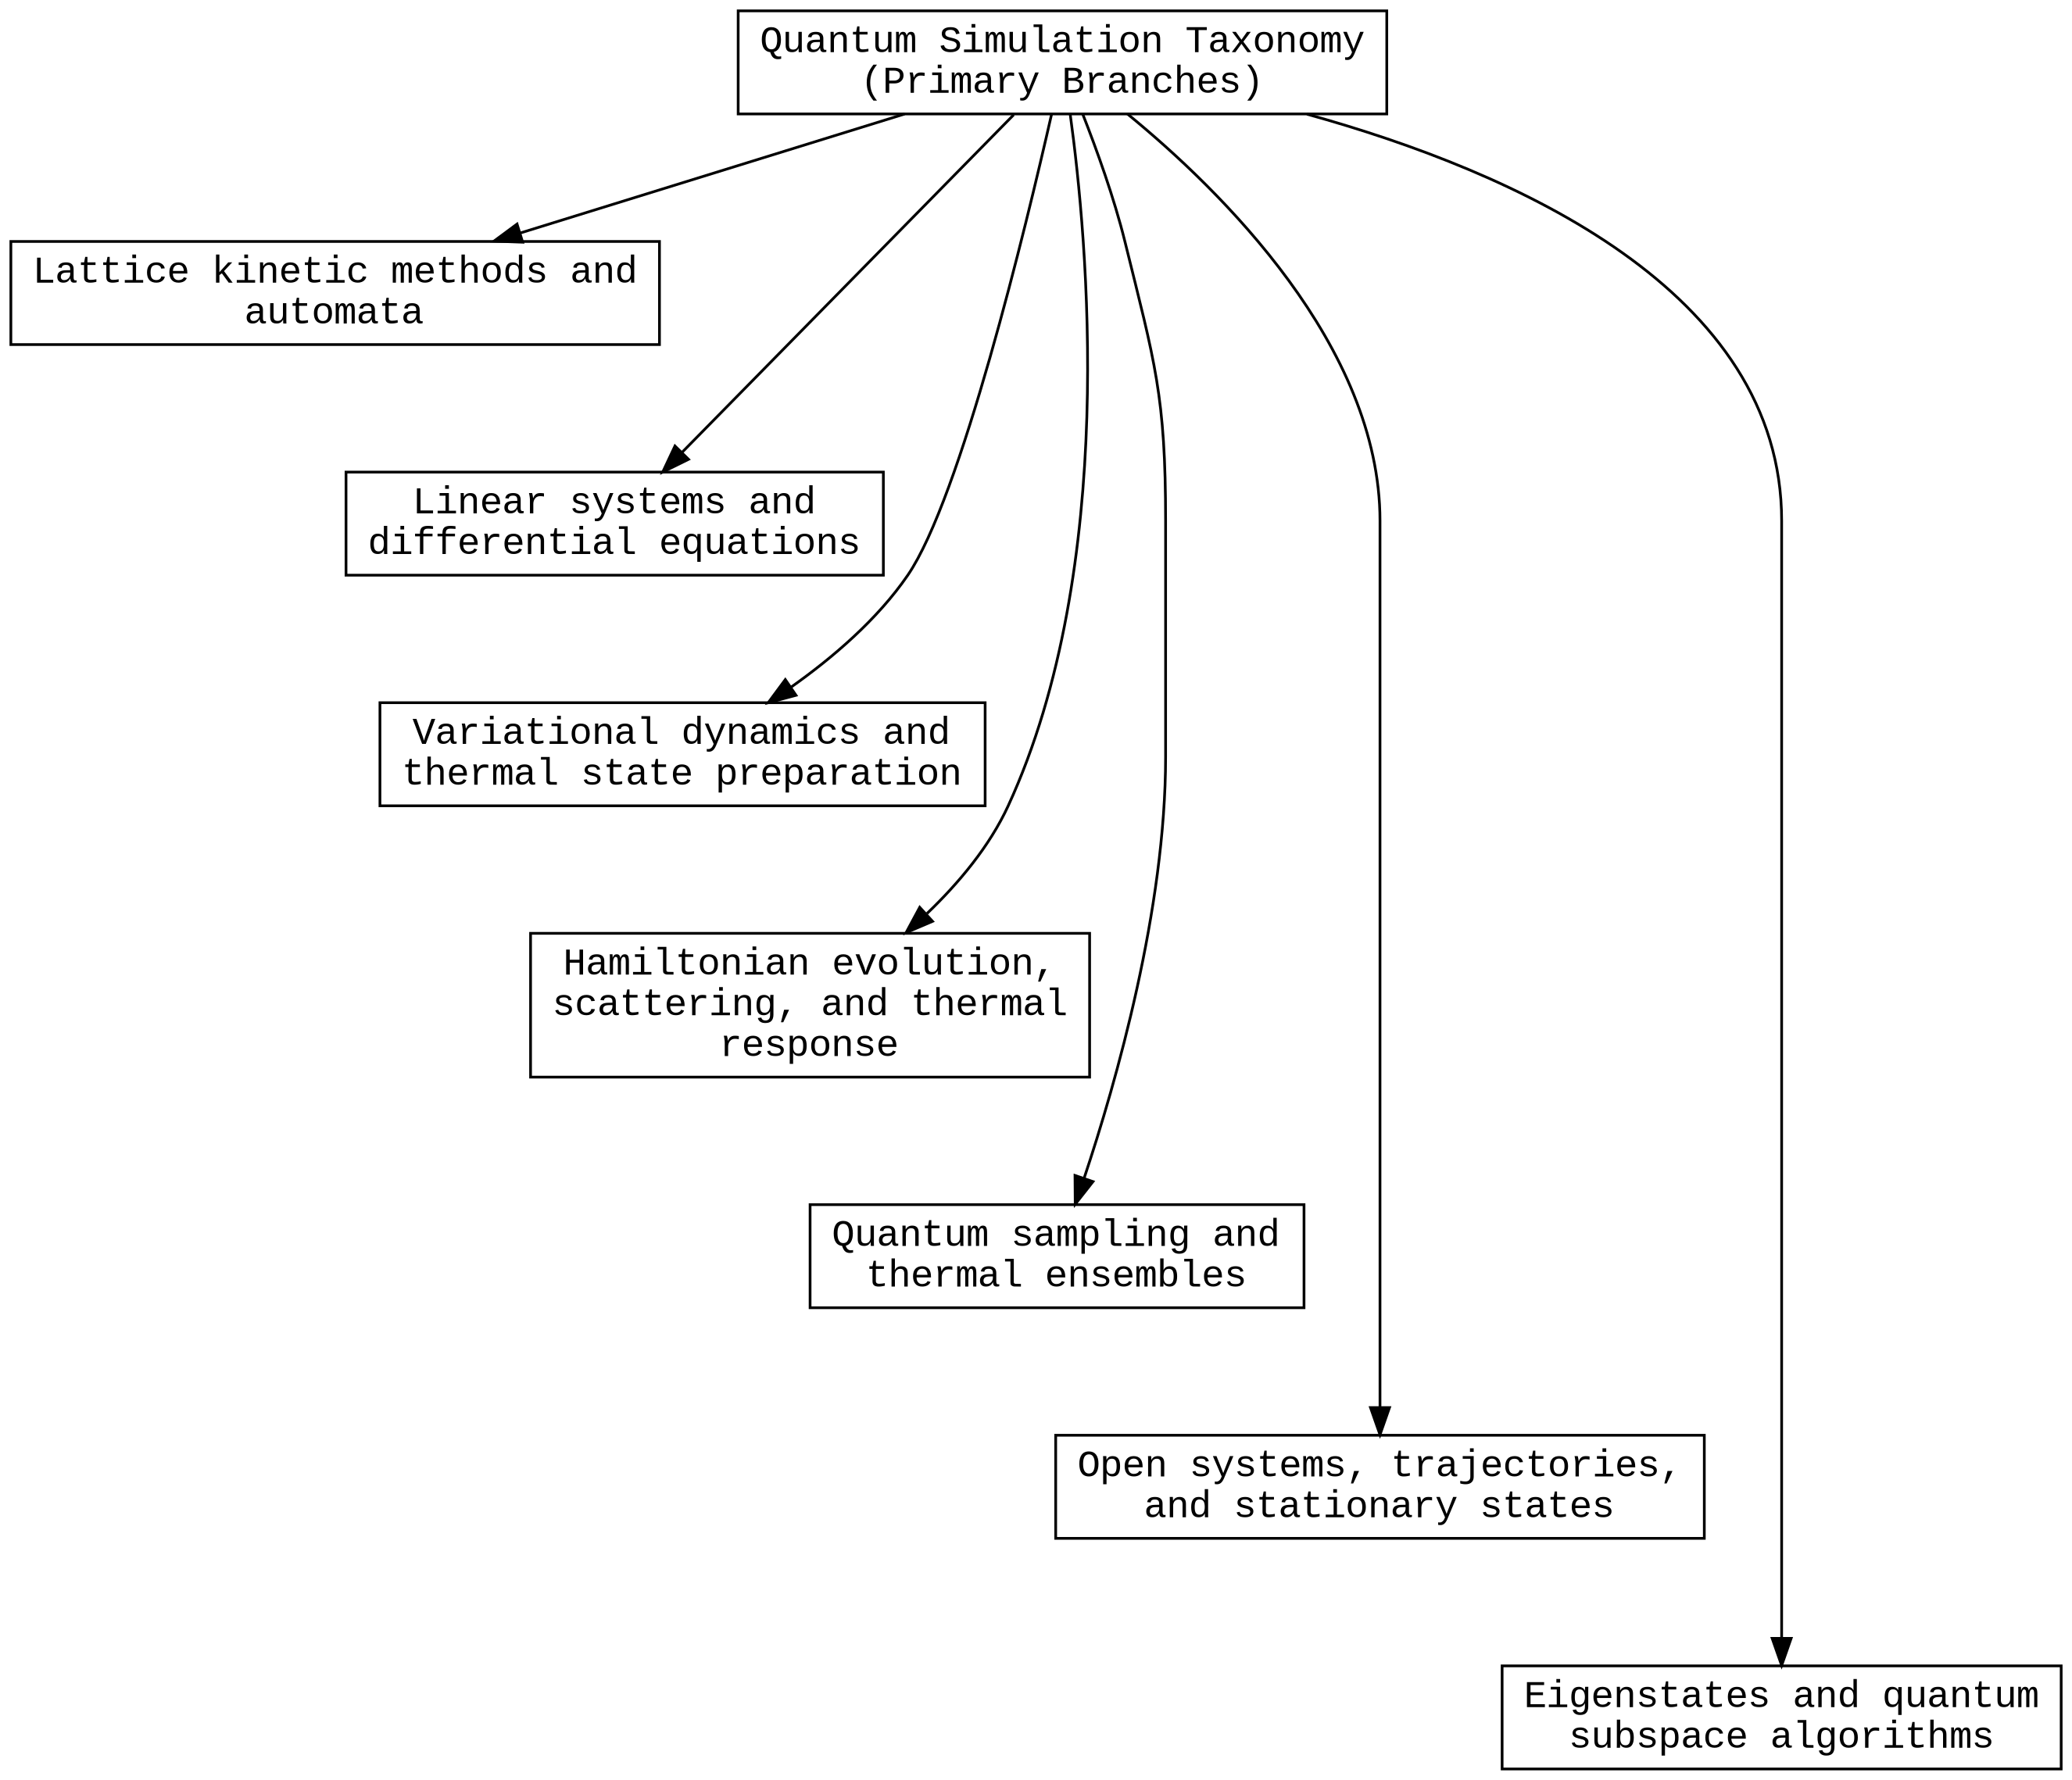

In [2]:
!uv pip install graphviz ipython

"""This script constructs short-depth quantum architecture graphs and renders them as in-memory objects.

Graphs avoid orthogonal edges and maintain an absolute monochrome aesthetic. Control parameters
defined at the module level dictate the precise font, resolution, and vertical spacing characteristics.
The script applies a hard character limit to each graphical node, cascades primary branches, and stretches
the diagrams vertically. The output displays interactive buttons enabling users to retrieve the images.
"""

import base64
import graphviz
from IPython.display import display, Image, HTML

# Control Knobs
GRAPH_DPI = "250"
NODE_FONT = "DejaVu Sans"
NODE_FONT_WEIGHT = "normal"
EDGE_ROUTING = "spline"
NODE_SHAPE = "box"
BACKGROUND_COLOR = "white"
FOREGROUND_COLOR = "black"
RANK_DIRECTION = "TB"
MAX_CHARACTERS_PER_LINE = 27
RANK_SEPARATION = "0.65"
VERTICAL_STAGGER_STEP = 1  # Multiplies the vertical drop distance across parallel branches

def wrap_text(text: str, max_width: int = MAX_CHARACTERS_PER_LINE) -> str:
    """Wraps text to a specified maximum width, hyphenating oversized strings.

    Args:
        text: The original string input.
        max_width: The maximum allowable characters per line.

    Returns:
        A formatted string featuring newline characters at proper intervals.
    """
    lines = []
    for paragraph in text.split('\n'):
        current_line = ""
        words = paragraph.split()
        for word in words:
            while len(word) > max_width:
                if current_line:
                    lines.append(current_line)
                    current_line = ""
                chunk = word[:max_width - 1] + "-"
                lines.append(chunk)
                word = word[max_width - 1:]

            if current_line:
                if len(current_line) + 1 + len(word) <= max_width:
                    current_line += " " + word
                else:
                    lines.append(current_line)
                    current_line = word
            else:
                current_line = word
        if current_line:
            lines.append(current_line)
    return '\n'.join(lines)

def init_graph(name: str) -> graphviz.Digraph:
    """Initializes a standardized Graphviz Digraph with module-level control parameters."""
    tree = graphviz.Digraph(format='png', name=name)
    tree.attr(
        dpi=GRAPH_DPI,
        splines=EDGE_ROUTING,
        bgcolor=BACKGROUND_COLOR,
        rankdir=RANK_DIRECTION,
        ranksep=RANK_SEPARATION
    )
    tree.attr(
        'node',
        shape=NODE_SHAPE,
        style='solid',
        color=FOREGROUND_COLOR,
        fontcolor=FOREGROUND_COLOR,
        fontname=NODE_FONT
    )
    tree.attr(
        'edge',
        color=FOREGROUND_COLOR,
        arrowhead='normal',
        fontname=NODE_FONT,
        fontsize='10'
    )
    return tree

def build_hardware_readiness_tree() -> graphviz.Digraph:
    """Constructs the directed Graphviz object outlining Hardware Readiness Tiers."""
    tree = init_graph('Hardware_Readiness')
    tree.node('Root', wrap_text('Hardware Readiness and Tiers'))

    tiers = [
        ('Tier I', 'Demonstrations and bounded prototypes'),
        ('Tier II', 'Structured hybrid workflows'),
        ('Tier III', 'Scalable coherent algorithms (fault tolerance oriented)'),
        ('Tier R', 'Construction-dependent research directions'),
        ('Tier C', 'Classical comparisons and support')
    ]

    for idx, (tier, desc) in enumerate(tiers):
        t_id = f'T_{idx}'
        tree.node(t_id, wrap_text(f'{tier}:\n{desc}'))
        tree.edge('Root', t_id, minlen=str((idx + 1) * VERTICAL_STAGGER_STEP))

    return tree

def build_heterogeneous_arch_tree() -> graphviz.Digraph:
    """Constructs the directed Graphviz object outlining the Heterogeneous Architecture."""
    tree = init_graph('Heterogeneous_Architecture')
    tree.node('Root', wrap_text('Heterogeneous Quantum Computer\n(Fault-Tolerant Compatible)'))

    components = [
        ('Main_QPU', 'Main QPU: Neutral-Atom (Rydberg/tweezer)'),
        ('CoProc', 'Co-Processor: Quantum Photonic IC (QPIC)'),
        ('Trans', 'Translator(s) & quantum transducers: μw ↔ optical'),
        ('QMem', 'Quantum Memory: Superconducting Cat (bosonic)'),
        ('Ancilla', 'Ancilla Layer: Transmons (tight to memories & readout)'),
        ('ClassCtrl', 'Classical Control & RAM (Cryo-CMOS, SFQ)')
    ]

    for idx, (c_id, desc) in enumerate(components):
        tree.node(c_id, wrap_text(desc))
        tree.edge('Root', c_id, minlen=str((idx + 1) * VERTICAL_STAGGER_STEP))

    return tree

def build_taxonomy_summary_tree() -> graphviz.Digraph:
    """Constructs the directed Graphviz object summarizing the primary Simulation Taxonomy."""
    tree = init_graph('Taxonomy_Summary')
    tree.node('Root', wrap_text('Quantum Simulation Taxonomy\n(Primary Branches)'))

    categories = [
        'Lattice kinetic methods and automata',
        'Linear systems and differential equations',
        'Variational dynamics and thermal state preparation',
        'Hamiltonian evolution, scattering, and thermal response',
        'Quantum sampling and thermal ensembles',
        'Open systems, trajectories, and stationary states',
        'Eigenstates and quantum subspace algorithms'
    ]

    for idx, cat in enumerate(categories):
        cat_id = f'Cat_{idx}'
        tree.node(cat_id, wrap_text(cat))
        tree.edge('Root', cat_id, minlen=str((idx + 1) * VERTICAL_STAGGER_STEP))

    return tree

def display_and_generate_download(tree: graphviz.Digraph, filename: str) -> None:
    """Renders the graph in memory and constructs a base64 encoded download button."""
    binary_png = tree.pipe(format='png')
    display(Image(data=binary_png))

    encoded_image = base64.b64encode(binary_png).decode('utf-8')


if __name__ == '__main__':
    readiness_tree = build_hardware_readiness_tree()
    display_and_generate_download(readiness_tree, 'hardware_readiness_tiers.png')

    arch_tree = build_heterogeneous_arch_tree()
    display_and_generate_download(arch_tree, 'heterogeneous_architecture.png')

    taxonomy_tree = build_taxonomy_summary_tree()
    display_and_generate_download(taxonomy_tree, 'taxonomy_summary.png')